<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [1]:
import urllib.request
urllib.request.urlretrieve('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv', 'survey-data.csv')

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



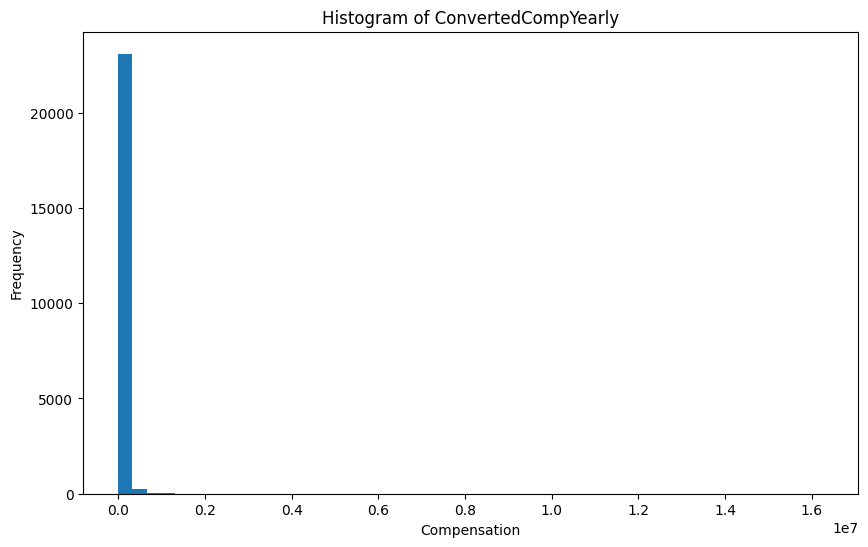

In [2]:
df['ConvertedCompYearly'].dropna().plot(kind='hist', bins=50, figsize=(10,6))
plt.title('Histogram of ConvertedCompYearly')
plt.xlabel('Compensation')
plt.ylabel('Frequency')
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



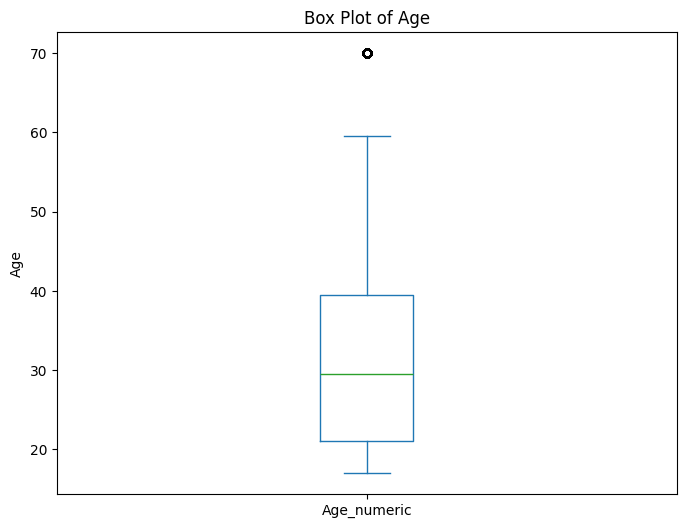

In [3]:
age_mapping = {'Under 18 years old': 17, '18-24 years old': 21, '25-34 years old': 29.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '55-64 years old': 59.5, '65 years or older': 70}
df['Age_numeric'] = df['Age'].map(age_mapping)
df['Age_numeric'].dropna().plot(kind='box', figsize=(8,6))
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



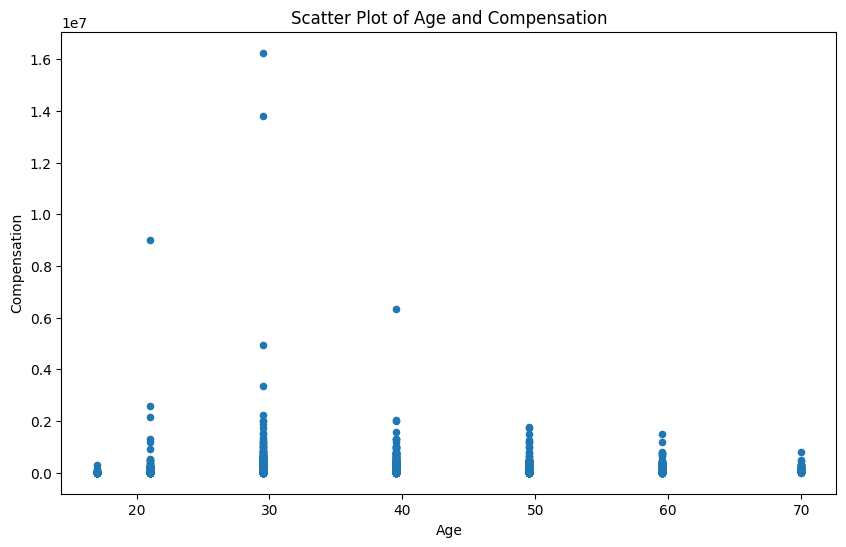

In [4]:
df.plot.scatter(x='Age_numeric', y='ConvertedCompYearly', figsize=(10,6))
plt.title('Scatter Plot of Age and Compensation')
plt.xlabel('Age')
plt.ylabel('Compensation')
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


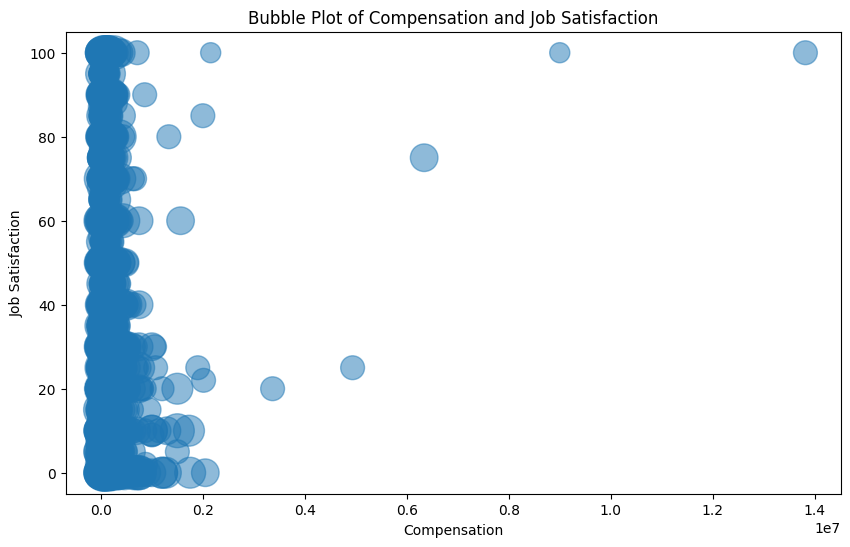

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(df['ConvertedCompYearly'], df['JobSatPoints_6'], s=df['Age_numeric']*10, alpha=0.5)
plt.title('Bubble Plot of Compensation and Job Satisfaction')
plt.xlabel('Compensation')
plt.ylabel('Job Satisfaction')
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



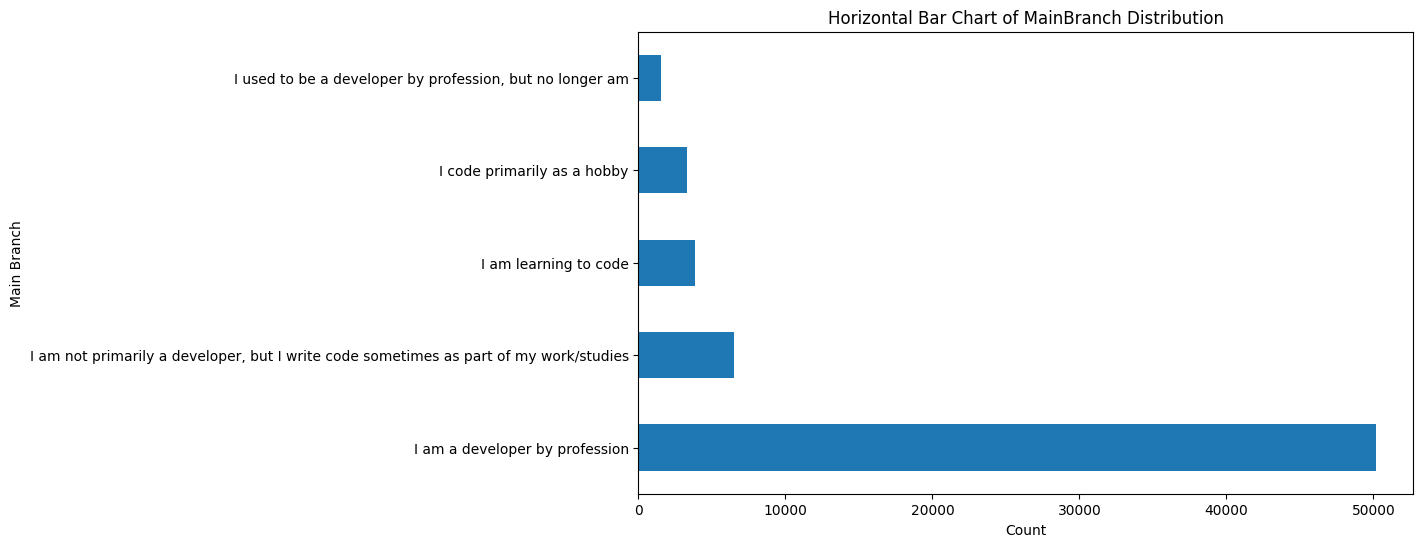

In [6]:
main_branch_counts = df['MainBranch'].value_counts()
main_branch_counts.plot(kind='barh', figsize=(10,6))
plt.title('Horizontal Bar Chart of MainBranch Distribution')
plt.xlabel('Count')
plt.ylabel('Main Branch')
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



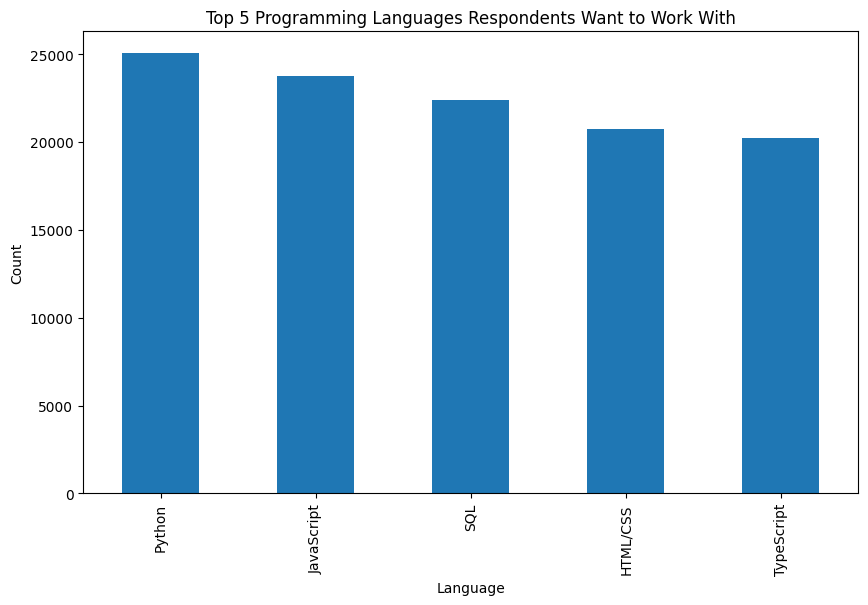

In [7]:
lang_counts = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts().head(5)
lang_counts.plot(kind='bar', figsize=(10,6))
plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Language')
plt.ylabel('Count')
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


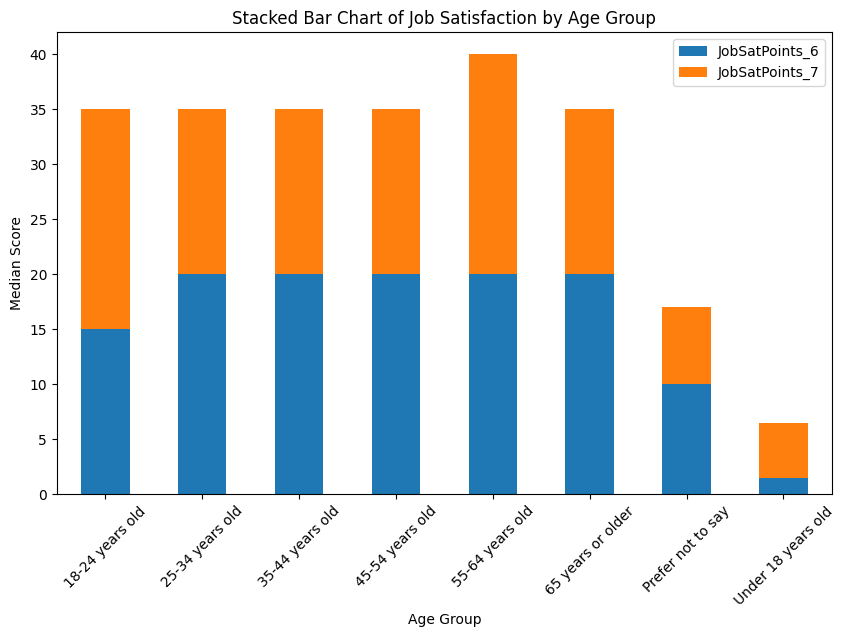

In [8]:
age_sat = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()
age_sat.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Stacked Bar Chart of Job Satisfaction by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Score')
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])
plt.xticks(rotation=45)
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



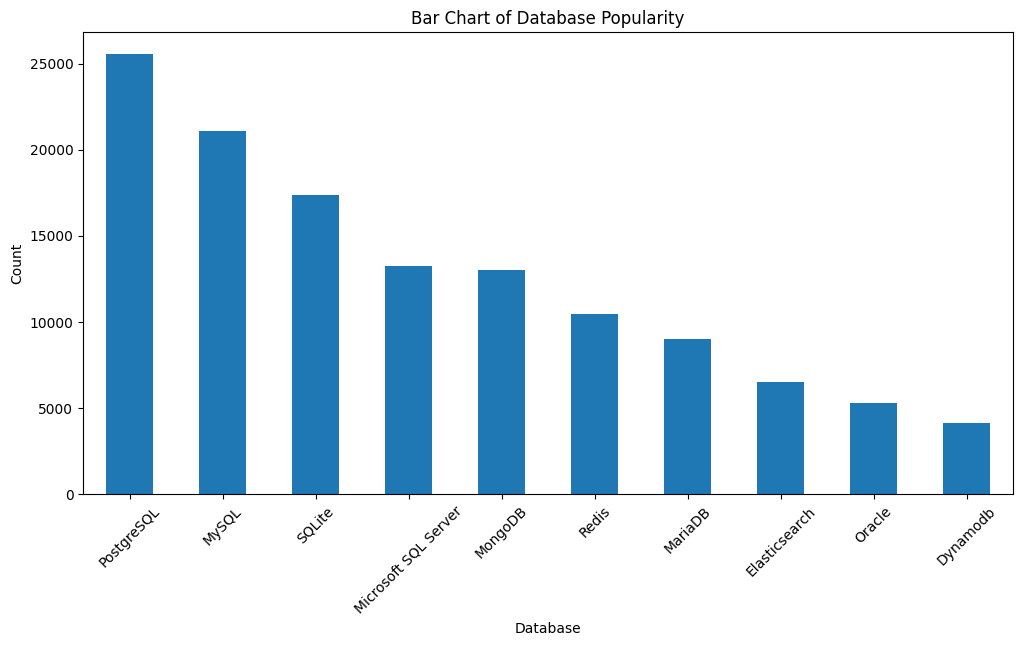

In [9]:
db_counts = df['DatabaseHaveWorkedWith'].str.split(';').explode().value_counts().head(10)
db_counts.plot(kind='bar', figsize=(12,6))
plt.title('Bar Chart of Database Popularity')
plt.xlabel('Database')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



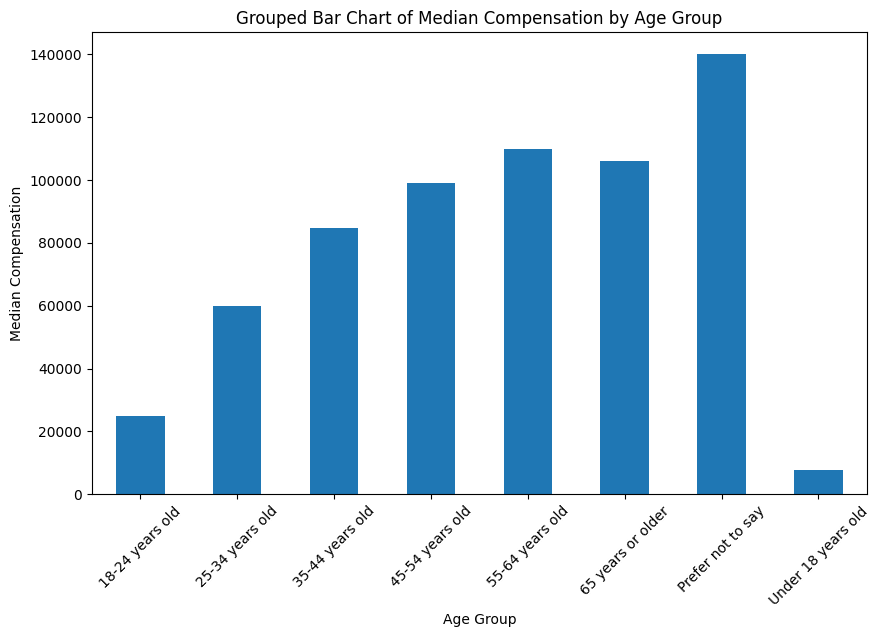

In [10]:
age_comp = df.groupby('Age')['ConvertedCompYearly'].median()
age_comp.plot(kind='bar', figsize=(10,6))
plt.title('Grouped Bar Chart of Median Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Compensation')
plt.xticks(rotation=45)
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



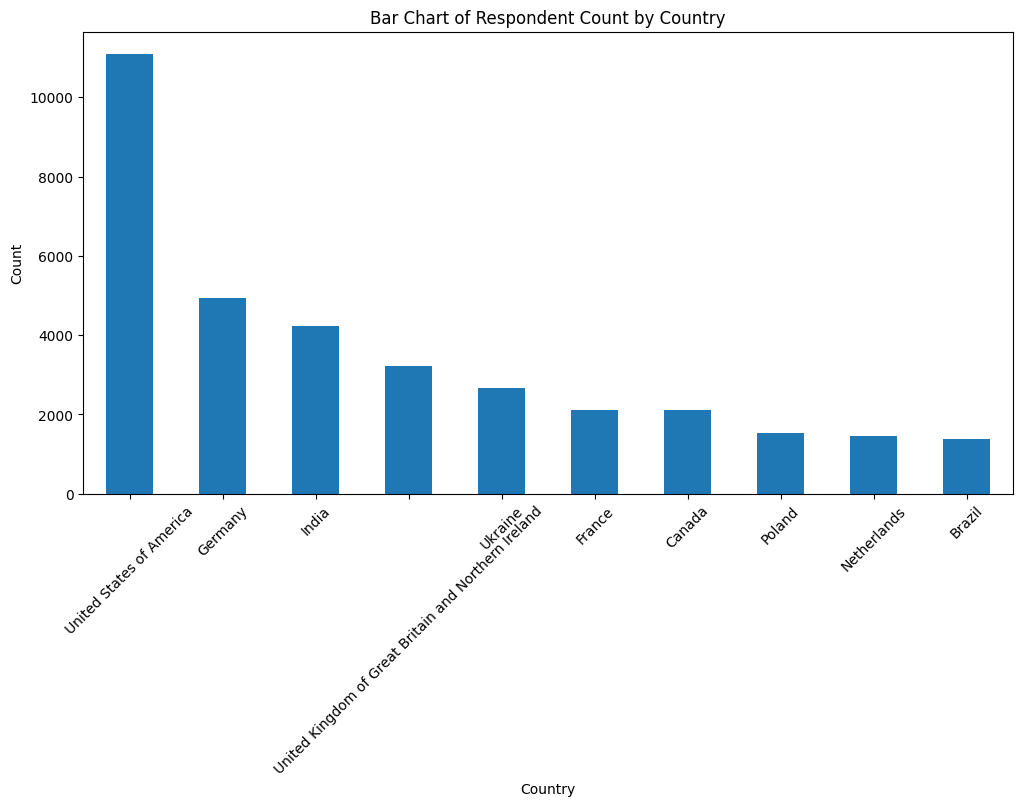

In [11]:
country_counts = df['Country'].value_counts().head(10)
country_counts.plot(kind='bar', figsize=(12,6))
plt.title('Bar Chart of Respondent Count by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
